# 05e — Baseline Comparison
**RouteRight AI — Stage 6 (Model Development)**

Merges the results from `05a`–`05d` into one systematic comparison. **This notebook trains nothing except the no-skill reference.** It reads the CSV files the four model notebooks saved, so run `05a`–`05d` first.

Because all four notebooks import the same `baseline_common.py`, the folds, threshold and metric definitions are identical; this notebook *verifies* that instead of assuming it.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

import baseline_common as bc

MODELS = ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]
X, y, train = bc.load_train(verbose=False)

folds_all = pd.concat([pd.read_csv(bc.OUT_DIR / f"baseline_{bc.slug(m)}_folds.csv") for m in MODELS], ignore_index=True)
oof_all = pd.concat([pd.read_csv(bc.OUT_DIR / f"baseline_{bc.slug(m)}_oof.csv") for m in MODELS], ignore_index=True)
full_all = pd.concat([pd.read_csv(bc.OUT_DIR / f"baseline_{bc.slug(m)}_full_fit.csv") for m in MODELS], ignore_index=True)
print("Loaded:", folds_all.groupby(["model", "variant"]).size().shape[0], "model/variant combinations")

Loaded: 8 model/variant combinations


## 1. Fairness check — all models saw identical folds

In [8]:
layouts = set()
for m in MODELS:
    g = folds_all[folds_all["model"] == m]
    layouts.add(tuple(zip(g["fold"], g["n_train"], g["n_val"], g["val_pos_rate"].round(6))))
assert len(layouts) == 1, "Models were validated on different folds!"

print("All four models were evaluated on identical folds (same sizes and validation positive rates): PASSED")
print("Variants per model:", folds_all.groupby("model").variant.unique().to_dict())

All four models were evaluated on identical folds (same sizes and validation positive rates): PASSED
Variants per model: {'Decision Tree': <StringArray>
['unweighted', 'weighted']
Length: 2, dtype: str, 'Gradient Boosting': <StringArray>
['unweighted', 'weighted']
Length: 2, dtype: str, 'Logistic Regression': <StringArray>
['unweighted', 'weighted']
Length: 2, dtype: str, 'Random Forest': <StringArray>
['unweighted', 'weighted']
Length: 2, dtype: str}


## 2. No-skill reference
A majority-class predictor (not a fifth algorithm). Its PR-AUC equals the positive rate of the validation blocks.

In [9]:
ref_folds, ref_oof = bc.run_reference(X, y)
folds_cmp = pd.concat([folds_all, ref_folds], ignore_index=True)
folds_cmp.to_csv(bc.OUT_DIR / "baseline_cv_folds.csv", index=False)

## 3. Results — cross-validated comparison (mean ± std over 5 time-ordered folds)

In [10]:
summary = bc.summarize(folds_cmp)
summary.to_csv(bc.OUT_DIR / "baseline_cv_summary.csv", index=False)
summary[["model", "variant", "pr_auc", "pr_auc_std", "f1", "recall", "precision", "accuracy", "roc_auc", "train_accuracy"]]

,model,variant,pr_auc,pr_auc_std,f1,recall,precision,accuracy,roc_auc,train_accuracy
0,Random Forest,weighted,0.7374,0.0603,0.6813,0.6929,0.6743,0.7147,0.7751,0.9894
1,Random Forest,unweighted,0.7373,0.0560,0.6801,0.7122,0.6581,0.7055,0.7733,0.9894
2,Gradient Boosting,weighted,0.7308,0.0700,0.6156,0.5723,0.6766,0.6893,0.7558,0.7498
3,Gradient Boosting,unweighted,0.7268,0.0721,0.6351,0.6455,0.6530,0.6837,0.7527,0.7525
4,Logistic Regression,unweighted,0.7178,0.0813,0.6245,0.6252,0.6634,0.6845,0.7501,0.7313
5,Logistic Regression,weighted,0.7175,0.0816,0.6207,0.5966,0.6748,0.6897,0.7498,0.7292
6,Decision Tree,weighted,0.5515,0.0689,0.6188,0.6344,0.6063,0.6509,0.6429,0.9894
7,Decision Tree,unweighted,0.5468,0.0697,0.6145,0.6361,0.5971,0.6440,0.6375,0.9894
8,Reference: majority class,n/a,0.4551,0.0917,0.5049,0.8000,0.3729,0.4907,0.5000,0.5399


In [11]:
# Per-fold PR-AUC for every model/variant (fold 1 has only ~3,500 training rows)
folds_cmp.pivot_table(index=["model", "variant"], columns="fold", values="pr_auc").round(3)

fold                                      1      2      3      4      5
model                     variant                                      
Decision Tree             unweighted  0.665  0.544  0.492  0.501  0.532
                          weighted    0.668  0.551  0.494  0.507  0.537
Gradient Boosting         unweighted  0.849  0.713  0.659  0.698  0.714
                          weighted    0.850  0.715  0.662  0.711  0.715
Logistic Regression       unweighted  0.862  0.701  0.666  0.677  0.684
                          weighted    0.862  0.699  0.666  0.677  0.684
Random Forest             unweighted  0.831  0.704  0.688  0.722  0.741
                          weighted    0.840  0.700  0.693  0.712  0.742
Reference: majority class n/a         0.611  0.453  0.426  0.374  0.411

In [12]:
# Per-fold gap to the no-skill level (PR-AUC minus the positive rate of that validation block)
gap = folds_cmp.assign(gain=folds_cmp.pr_auc - folds_cmp.val_pos_rate).pivot_table(index=["model", "variant"], columns="fold", values="gain").round(3)
gap["mean_gain"] = gap.mean(axis=1).round(3)
gap.sort_values("mean_gain", ascending=False)

fold                                      1      2      3      4      5  \
model                     variant                                         
Random Forest             weighted    0.229  0.247  0.267  0.338  0.331   
                          unweighted  0.220  0.251  0.262  0.348  0.330   
Gradient Boosting         weighted    0.238  0.263  0.236  0.337  0.304   
                          unweighted  0.238  0.260  0.233  0.324  0.303   
Logistic Regression       weighted    0.251  0.246  0.240  0.303  0.273   
                          unweighted  0.251  0.248  0.240  0.303  0.273   
Decision Tree             weighted    0.057  0.098  0.068  0.133  0.126   
                          unweighted  0.054  0.091  0.066  0.126  0.121   
Reference: majority class n/a         0.000  0.000  0.000  0.000  0.000   

fold                                  mean_gain  
model                     variant                
Random Forest             weighted        0.282  
                          unweighted      0.282  
Gradient Boosting         weighted        0.276  
                          unweighted      0.272  
Logistic Regression       weighted        0.263  
                          unweighted      0.263  
Decision Tree             weighted        0.096  
                          unweighted      0.092  
Reference: majority class n/a             0.000

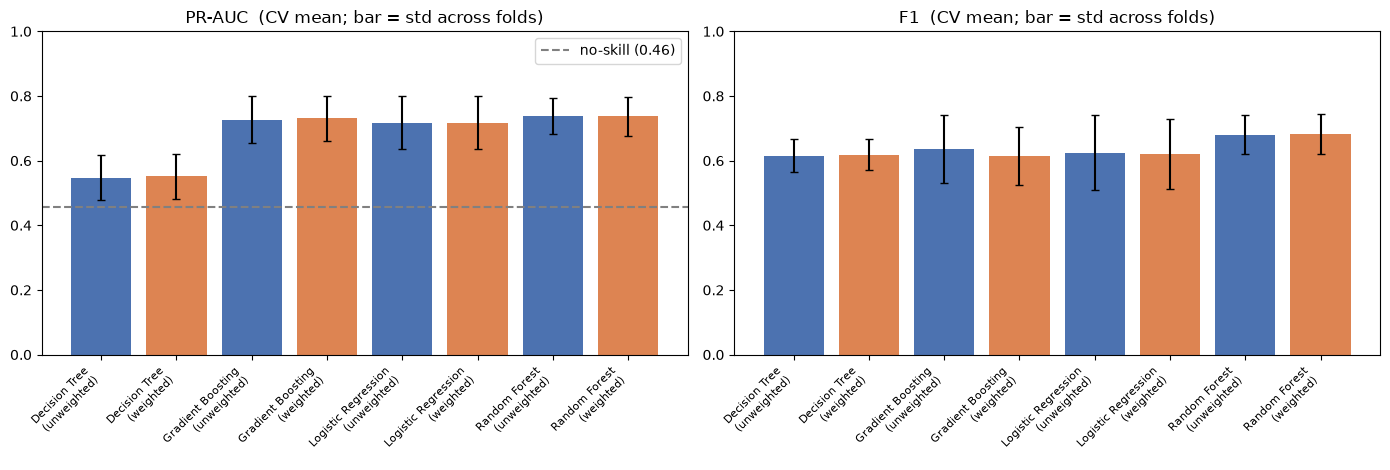

In [13]:
plot_df = summary[~summary.model.str.startswith("Reference")].sort_values(["model", "variant"]).copy()
plot_df["label"] = plot_df["model"] + "\n(" + plot_df["variant"] + ")"
colors = ["#4C72B0" if v == "unweighted" else "#DD8452" for v in plot_df["variant"]]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, met in zip(axes, ["pr_auc", "f1"]):
    ax.bar(range(len(plot_df)), plot_df[met], yerr=plot_df[met + "_std"], color=colors, capsize=3)
    ax.set_xticks(range(len(plot_df))); ax.set_xticklabels(plot_df["label"], rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{met.upper().replace('_', '-')}  (CV mean; bar = std across folds)"); ax.set_ylim(0, 1)
noskill = summary.loc[summary.model.str.startswith("Reference"), "pr_auc"].iloc[0]
axes[0].axhline(noskill, color="grey", ls="--", label=f"no-skill ({noskill:.2f})"); axes[0].legend()
plt.tight_layout(); plt.savefig(bc.OUT_DIR / "baseline_cv_comparison.png", dpi=130); plt.show()

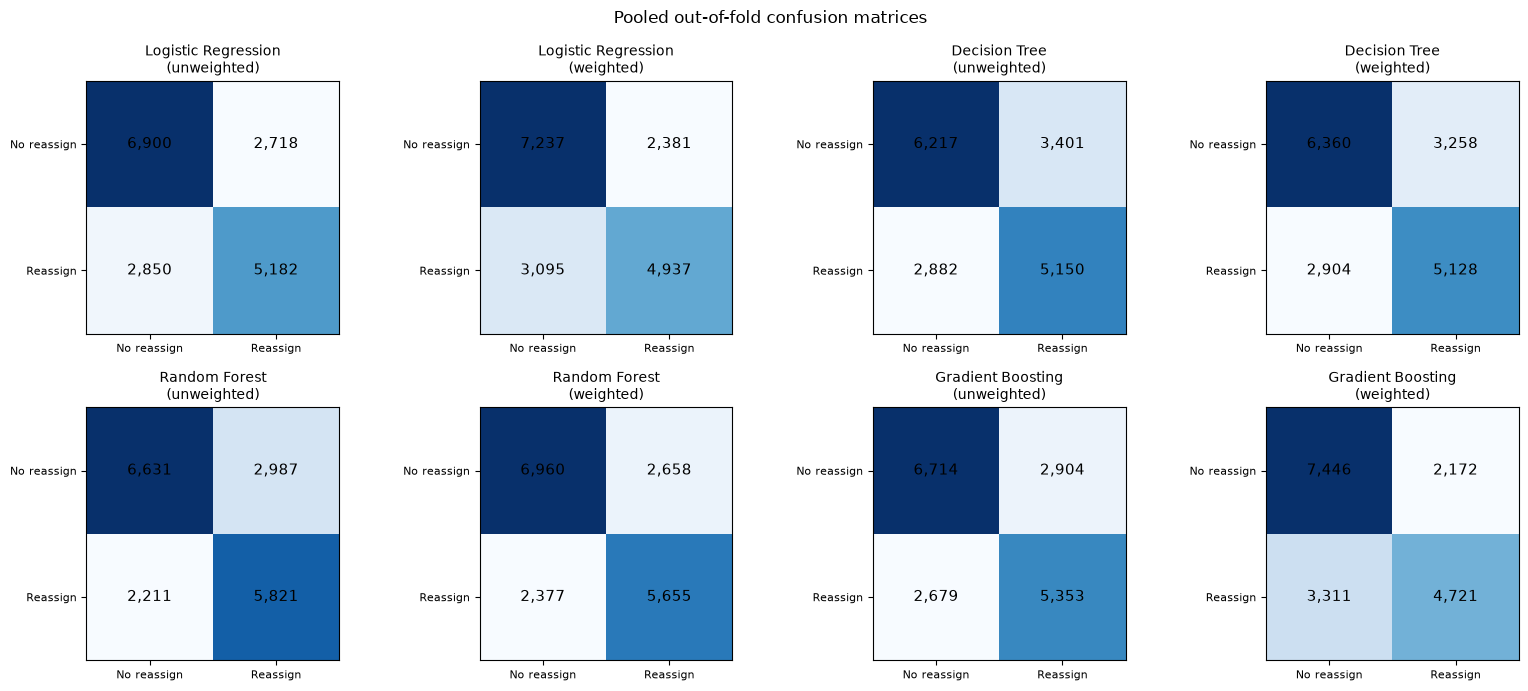

In [14]:
# Confusion matrices, pooled out-of-fold predictions. Rows = actual, columns = predicted.
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (m, v) in zip(axes.ravel(), [(m, v) for m in MODELS for v in ["unweighted", "weighted"]]):
    part = oof_all[(oof_all.model == m) & (oof_all.variant == v)]
    cm = confusion_matrix(part.y_true, part.y_pred)
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=11)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No reassign", "Reassign"], fontsize=8); ax.set_yticklabels(["No reassign", "Reassign"], fontsize=8)
    ax.set_title(f"{m}\n({v})", fontsize=10)
plt.suptitle("Pooled out-of-fold confusion matrices")
plt.tight_layout(); plt.savefig(bc.OUT_DIR / "baseline_confusion_matrices.png", dpi=130); plt.show()

## 4. Training-accuracy ceiling
Within each group of identical feature rows, the best any model can do is predict the group's majority label. This gives the exact maximum achievable training accuracy (the README's estimate of ~97–98% was approximate).

In [15]:
grp = train.groupby(list(X.columns))[bc.TARGET].agg(pos="sum", n="count")
ceiling = np.maximum(grp["pos"], grp["n"] - grp["pos"]).sum() / len(train)
print(f"Maximum achievable training accuracy: {ceiling:.4f}")
full_all.assign(pct_of_ceiling=(full_all.train_accuracy_full / ceiling).round(4))

Maximum achievable training accuracy: 0.9896


,model,variant,train_accuracy_full,train_f1_full,pct_of_ceiling
0,Logistic Regression,unweighted,0.7180,0.6887,0.7256
1,Logistic Regression,weighted,0.7168,0.7015,0.7244
2,Decision Tree,unweighted,0.9896,0.9890,1.0000
3,Decision Tree,weighted,0.9896,0.9890,1.0000
4,Random Forest,unweighted,0.9896,0.9889,1.0000
5,Random Forest,weighted,0.9896,0.9889,1.0000
6,Gradient Boosting,unweighted,0.7309,0.6944,0.7386
7,Gradient Boosting,weighted,0.7266,0.7014,0.7343


## 5. Observations (numbers from the run above — re-check if you change anything)

**Ranking by PR-AUC (CV mean):** Random Forest ≈ 0.737 > Gradient Boosting ≈ 0.73 > Logistic Regression ≈ 0.718 ≫ Decision Tree ≈ 0.55; no-skill ≈ 0.455.

1. **The top three are statistically hard to separate.** Their PR-AUC differences (≈ 0.01–0.02) are far smaller than the fold-to-fold std (≈ 0.05–0.08). Do not claim a winner from the baseline alone — tuning and per-fold evidence decide it.
2. **Single tree ≪ forest.** The Decision Tree and Random Forest both memorise the training set (0.99 train accuracy) but validate very differently (0.55 vs 0.74 PR-AUC): averaging decorrelated trees removes most of the variance.
3. **Training-accuracy ceiling is 98.96%** (exact). The Decision Tree and Random Forest reach it, i.e. they have memorised every learnable training row. Gradient Boosting and Logistic Regression (≈ 0.73) are far from it — under-fitted rather than over-fitted.
4. **Logistic Regression is competitive** (within ≈ 0.02 of the ensembles). The predicted damage from the impact/urgency/priority collinearity did not appear: L2 regularisation shrinks all three coefficients toward zero. The signal sits mainly in `assignment_group` and `u_symptom` one-hot columns, which act roughly additively — so nonlinearity/interactions add only modestly here.
5. **Class weighting matters little for ranking (PR-AUC) but shifts the precision/recall trade-off** at the 0.5 threshold. For Gradient Boosting and Logistic Regression it lowers recall, because in the early folds the training set is majority-positive and `balanced` up-weights the *negative* class (a consequence of the documented target drift).
6. **Fold 1 scores highest partly by chance:** its validation block is 61% positive, and no-skill PR-AUC equals that rate. Use the gain-over-no-skill table above rather than raw fold scores.
7. **Absolute performance is modest** (best PR-AUC ≈ 0.74, accuracy ≈ 0.71, F1 ≈ 0.68): only information known at ticket creation is used, so reassignment appears only partly predictable from it.

**Carry-forward to Stage 7 (`06_Model_Tuning`):** tune Random Forest and Gradient Boosting first; regularise the Decision Tree (`max_depth`, `min_samples_leaf`, `ccp_alpha`); tune `C` for Logistic Regression; test dropping `priority_encoded`; use permutation importance to check the time-of-day features. Keep `TimeSeriesSplit` and keep the test set sealed.